# 02 — Embedding Comparison: TF-IDF vs FinBERT

**Goal:** Compare text representations while keeping the classifier fixed (Logistic Regression).  
**Dataset path:** `C:/Users/user/Documents/data_science_bootcamp_challenges_project/capstone_project/amit_kedia_dataset.csv`

## Methodology
To fairly compare embeddings, **the same classifier (Logistic Regression)** is used for all representations.  
Only the feature extraction step changes.

| Embedding | Description |
|-----------|-------------|
| TF-IDF | Sparse lexical features based on term frequency | 
| FinBERT | Contextual embeddings pre-trained on financial text |
| BERT (optional) | General-purpose contextual embeddings |

**Why FinBERT over BERT?**  
FinBERT (`ProsusAI/finbert`) was pre-trained on financial corpora (10-K filings, earnings calls), making it domain-aware for terms like *going concern*, *material weakness*, or *revenue restatement*.

## 0. Imports and configuration

In [18]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve
)

plt.style.use("ggplot")
pd.set_option("display.max_columns", None)

FILE_PATH = r"C:/Users/user/Documents/data_science_bootcamp_challenges_project/capstone_project/amit_kedia_dataset.csv"
RANDOM_STATE = 42

print("Libraries loaded.")

Libraries loaded.


## 1. Load and prepare the dataset

In [9]:
df = pd.read_csv(FILE_PATH).drop_duplicates().reset_index(drop=True)
print("Shape:", df.shape)
print("Class distribution:")
print(df["Fraud"].value_counts())
df.head()

Shape: (170, 2)
Class distribution:
Fraud
yes    85
no     85
Name: count, dtype: int64


,Fillings,Fraud
0,nanitem 14 exhibits financial statements repor...,yes
1,item 14 principal accounting fees services mat...,no
2,item 14 exhibits financial statements schedule...,yes
3,item 14 exhibits financial statement schedules...,yes
4,item 14 exhibits financial statement schedules...,no


In [10]:
def clean_text(text):
    text = str(text)
    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    text = text.lower()
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean_text"] = df["Fillings"].astype(str).apply(clean_text)
df["target"] = df["Fraud"].map({"no": 0, "yes": 1})

X = df["clean_text"]
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"Train: {len(X_train)} samples")
print(f"Test:  {len(X_test)} samples")
print(f"Train fraud rate: {y_train.mean():.2%}")
print(f"Test  fraud rate: {y_test.mean():.2%}")

Train: 136 samples
Test:  34 samples
Train fraud rate: 50.00%
Test  fraud rate: 50.00%


## 2. Evaluation helpers

In [11]:
def evaluate(y_true, y_pred, y_prob=None, name="Model"):
    """Compute all relevant fraud detection metrics."""
    metrics = {
        "model": name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1_score": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_prob) if y_prob is not None else np.nan
    }
    return metrics

def plot_confusion(y_true, y_pred, title, ax=None):
    cm = confusion_matrix(y_true, y_pred)
    if ax is None:
        fig, ax = plt.subplots(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Non-Fraud", "Fraud"],
                yticklabels=["Non-Fraud", "Fraud"])
    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

results_list = []
predictions_dict = {}
probas_dict = {}

## 3. Embedding 1 — TF-IDF + Logistic Regression (Baseline)

In [12]:
tfidf_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=5000, stop_words="english", ngram_range=(1, 2))),
    ("clf", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE))
])

tfidf_pipeline.fit(X_train, y_train)
tfidf_pred = tfidf_pipeline.predict(X_test)
tfidf_prob = tfidf_pipeline.predict_proba(X_test)[:, 1]

tfidf_results = evaluate(y_test, tfidf_pred, tfidf_prob, "TF-IDF + Logistic Regression")
results_list.append(tfidf_results)
predictions_dict["TF-IDF"] = tfidf_pred
probas_dict["TF-IDF"] = tfidf_prob

print(classification_report(y_test, tfidf_pred, target_names=["Non-Fraud", "Fraud"]))
pd.DataFrame([tfidf_results]).round(4)

              precision    recall  f1-score   support

   Non-Fraud       1.00      0.76      0.87        17
       Fraud       0.81      1.00      0.89        17

    accuracy                           0.88        34
   macro avg       0.90      0.88      0.88        34
weighted avg       0.90      0.88      0.88        34



,model,accuracy,precision,recall,f1_score,roc_auc
0,TF-IDF + Logistic Regression,0.8824,0.8095,1.0,0.8947,0.9896


In [13]:
# 5-fold cross-validation for robustness (important on small datasets)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_scores = cross_val_score(tfidf_pipeline, X, y, cv=cv, scoring="f1", error_score="raise")

print(f"TF-IDF 5-Fold CV F1 scores: {cv_scores.round(3)}")
print(f"Mean: {cv_scores.mean():.4f} | Std: {cv_scores.std():.4f}")

TF-IDF 5-Fold CV F1 scores: [0.829 0.872 0.778 0.882 0.78 ]
Mean: 0.8283 | Std: 0.0439


### Top features driving fraud predictions

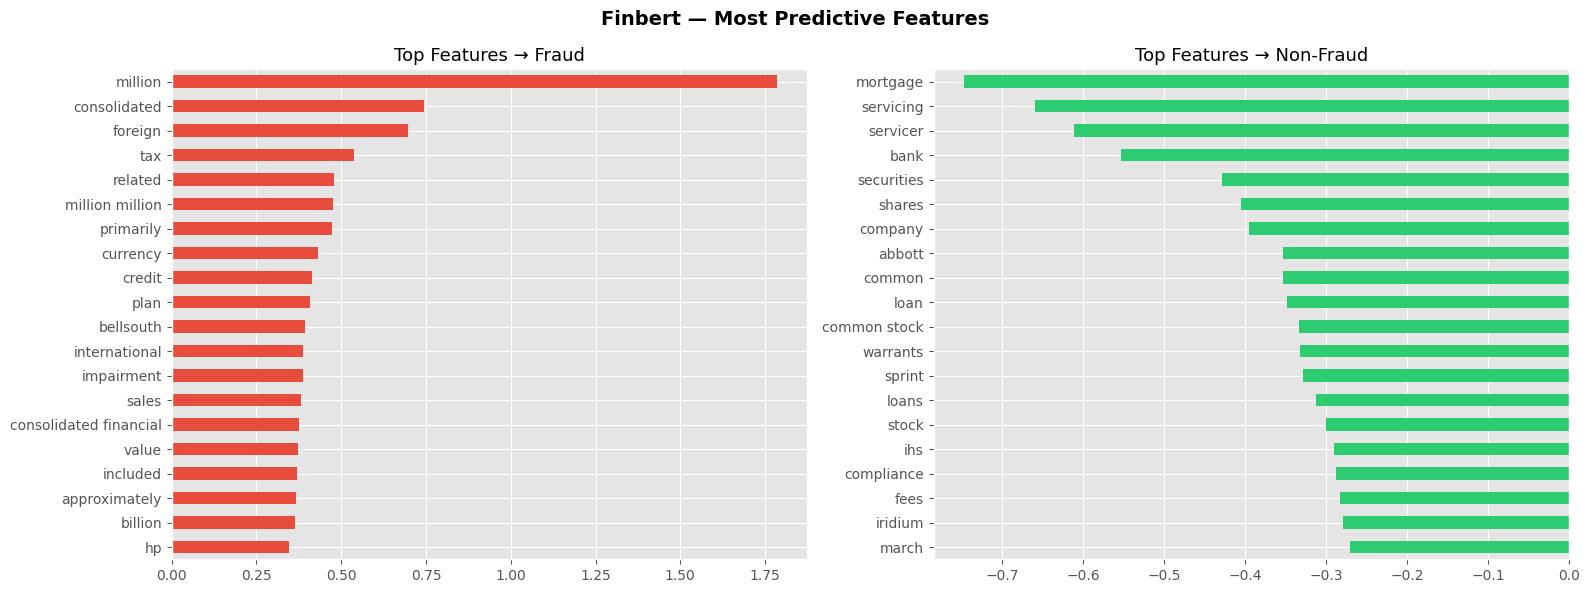

In [14]:
vectorizer = tfidf_pipeline.named_steps["tfidf"]
clf = tfidf_pipeline.named_steps["clf"]

feature_names = vectorizer.get_feature_names_out()
coef = clf.coef_[0]

top_n = 20
top_fraud_idx = np.argsort(coef)[-top_n:][::-1]
top_nonfraud_idx = np.argsort(coef)[:top_n]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

pd.Series(coef[top_fraud_idx], index=feature_names[top_fraud_idx]).plot(
    kind="barh", ax=axes[0], color="#e74c3c")
axes[0].set_title("Top Features → Fraud", fontsize=13)
axes[0].invert_yaxis()

pd.Series(coef[top_nonfraud_idx], index=feature_names[top_nonfraud_idx]).plot(
    kind="barh", ax=axes[1], color="#2ecc71")
axes[1].set_title("Top Features → Non-Fraud", fontsize=13)
axes[1].invert_yaxis()

plt.suptitle("Finbert — Most Predictive Features", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 4. Embedding 2 — FinBERT + Logistic Regression

**FinBERT** (`ProsusAI/finbert`) is a BERT model pre-trained on financial text.  
It understands domain-specific terms like *going concern*, *material weakness*, *restatement* in context.

> ⚠️ **Requirements:** `pip install transformers torch`  
> Set `USE_FINBERT = True` to run. On CPU it may take ~10–30 min depending on dataset size.  
> On GPU it runs in a few minutes.

In [19]:
USE_FINBERT = True  # Set to False to skip

if USE_FINBERT:
    import torch
    from transformers import AutoTokenizer, AutoModel

    # Force offline mode — use cached model, skip Hugging Face network check
    os.environ["TRANSFORMERS_OFFLINE"] = "1"

    device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"Using device: {device}")

    FINBERT_MODEL = "ProsusAI/finbert"
    finbert_tokenizer = AutoTokenizer.from_pretrained(FINBERT_MODEL)
    finbert_model = AutoModel.from_pretrained(FINBERT_MODEL).to(device)
    print("FinBERT loaded.")

    def get_finbert_embeddings(texts, tokenizer, model, max_length=256, batch_size=8):
        """Extract [CLS] token embeddings from FinBERT in batches."""
        model.eval()
        all_embeddings = []
        for i in range(0, len(texts), batch_size):
            batch = list(texts[i:i + batch_size])
            encoded = tokenizer(batch, padding=True, truncation=True,
                                max_length=max_length, return_tensors="pt")
            encoded = {k: v.to(device) for k, v in encoded.items()}
            with torch.no_grad():
                outputs = model(**encoded)
                cls_emb = outputs.last_hidden_state[:, 0, :].cpu().numpy()
            all_embeddings.append(cls_emb)
            if (i // batch_size) % 10 == 0:
                print(f"  Processed {min(i + batch_size, len(texts))}/{len(texts)} samples...")
        return np.vstack(all_embeddings)

    print("Extracting training embeddings...")
    X_train_finbert = get_finbert_embeddings(X_train.tolist(), finbert_tokenizer, finbert_model)
    print("Extracting test embeddings...")
    X_test_finbert = get_finbert_embeddings(X_test.tolist(), finbert_tokenizer, finbert_model)
    print(f"Embedding shapes — Train: {X_train_finbert.shape}, Test: {X_test_finbert.shape}")

    # Save train/test embeddings
    np.save("X_train_finbert.npy", X_train_finbert)
    np.save("X_test_finbert.npy", X_test_finbert)
    print("Train/test embeddings saved to disk.")

    # ↓ ADD THIS — save full dataset embeddings for cross-validation in Notebook 03
    print("Extracting full dataset embeddings for cross-validation...")
    X_full_finbert = get_finbert_embeddings(X.tolist(), finbert_tokenizer, finbert_model)
    np.save("X_full_finbert.npy", X_full_finbert)
    print(f"Full dataset embeddings saved — shape: {X_full_finbert.shape}")

else:
    print("Skipping FinBERT. Set USE_FINBERT = True to run.")

Using device: cpu
FinBERT loaded.
Extracting training embeddings...
  Processed 8/136 samples...
  Processed 88/136 samples...
Extracting test embeddings...
  Processed 8/34 samples...
Embedding shapes — Train: (136, 768), Test: (34, 768)
Train/test embeddings saved to disk.
Extracting full dataset embeddings for cross-validation...
  Processed 8/170 samples...
  Processed 88/170 samples...
  Processed 168/170 samples...
Full dataset embeddings saved — shape: (170, 768)


In [20]:
if USE_FINBERT:
    # Option: load saved embeddings if already computed
    # X_train_finbert = np.load("X_train_finbert.npy")
    # X_test_finbert = np.load("X_test_finbert.npy")

    finbert_clf = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE)
    finbert_clf.fit(X_train_finbert, y_train)

    finbert_pred = finbert_clf.predict(X_test_finbert)
    finbert_prob = finbert_clf.predict_proba(X_test_finbert)[:, 1]

    finbert_results = evaluate(y_test, finbert_pred, finbert_prob, "FinBERT + Logistic Regression")
    results_list.append(finbert_results)
    predictions_dict["FinBERT"] = finbert_pred
    probas_dict["FinBERT"] = finbert_prob

    print(classification_report(y_test, finbert_pred, target_names=["Non-Fraud", "Fraud"]))
    display(pd.DataFrame([finbert_results]).round(4))
else:
    print("FinBERT not run.")

              precision    recall  f1-score   support

   Non-Fraud       0.62      0.76      0.68        17
       Fraud       0.69      0.53      0.60        17

    accuracy                           0.65        34
   macro avg       0.66      0.65      0.64        34
weighted avg       0.66      0.65      0.64        34



,model,accuracy,precision,recall,f1_score,roc_auc
0,FinBERT + Logistic Regression,0.6471,0.6923,0.5294,0.6,0.782


In [21]:
if USE_FINBERT:
    from sklearn.model_selection import cross_val_score, StratifiedKFold
    import numpy as np

    # Rebuild full X for cross-validation
    print("Computing FinBERT embeddings on full dataset for cross-validation...")
    X_full_finbert = get_finbert_embeddings(X.tolist(), finbert_tokenizer, finbert_model)

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    clf_cv = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE)
    cv_scores_finbert = cross_val_score(clf_cv, X_full_finbert, y, cv=cv, scoring="f1")

    print(f"FinBERT 5-Fold CV F1 scores: {cv_scores_finbert.round(3)}")
    print(f"Mean: {cv_scores_finbert.mean():.4f} | Std: {cv_scores_finbert.std():.4f}")
else:
    print("Skipping cross-validation for FinBERT (not run).")

Computing FinBERT embeddings on full dataset for cross-validation...
  Processed 8/170 samples...
  Processed 88/170 samples...
  Processed 168/170 samples...
FinBERT 5-Fold CV F1 scores: [0.7   0.688 0.75  0.647 0.683]
Mean: 0.6935 | Std: 0.0333


## 5. Embedding 3 — BERT + Logistic Regression (Optional)

This is optional. General BERT is included for completeness, but FinBERT is expected to outperform it on financial filings.

In [11]:
USE_BERT = True  # Set to True to run

if USE_BERT:
    import torch
    from transformers import AutoTokenizer, AutoModel

    device = "cuda" if torch.cuda.is_available() else "cpu"
    BERT_MODEL = "bert-base-uncased"
    bert_tokenizer = AutoTokenizer.from_pretrained(BERT_MODEL)
    bert_model = AutoModel.from_pretrained(BERT_MODEL).to(device)

    def get_bert_embeddings(texts, tokenizer, model, max_length=256, batch_size=8):
        model.eval()
        all_embeddings = []
        for i in range(0, len(texts), batch_size):
            batch = list(texts[i:i + batch_size])
            encoded = tokenizer(batch, padding=True, truncation=True,
                                max_length=max_length, return_tensors="pt")
            encoded = {k: v.to(device) for k, v in encoded.items()}
            with torch.no_grad():
                out = model(**encoded)
                all_embeddings.append(out.last_hidden_state[:, 0, :].cpu().numpy())
        return np.vstack(all_embeddings)

    X_train_bert = get_bert_embeddings(X_train.tolist(), bert_tokenizer, bert_model)
    X_test_bert = get_bert_embeddings(X_test.tolist(), bert_tokenizer, bert_model)

    bert_clf = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE)
    bert_clf.fit(X_train_bert, y_train)

    bert_pred = bert_clf.predict(X_test_bert)
    bert_prob = bert_clf.predict_proba(X_test_bert)[:, 1]

    bert_results = evaluate(y_test, bert_pred, bert_prob, "BERT + Logistic Regression")
    results_list.append(bert_results)
    predictions_dict["BERT"] = bert_pred
    probas_dict["BERT"] = bert_prob

    print(classification_report(y_test, bert_pred, target_names=["Non-Fraud", "Fraud"]))
    display(pd.DataFrame([bert_results]).round(4))
else:
    print("BERT skipped. Set USE_BERT = True to run.")

              precision    recall  f1-score   support

   Non-Fraud       0.68      0.76      0.72        17
       Fraud       0.73      0.65      0.69        17

    accuracy                           0.71        34
   macro avg       0.71      0.71      0.70        34
weighted avg       0.71      0.71      0.70        34



,model,accuracy,precision,recall,f1_score,roc_auc
0,BERT + Logistic Regression,0.7059,0.7333,0.6471,0.6875,0.737


## 6. Embedding comparison

In [12]:
comparison_df = pd.DataFrame(results_list).sort_values("f1_score", ascending=False)
display(comparison_df.round(4))

,model,accuracy,precision,recall,f1_score,roc_auc
0,TF-IDF + Logistic Regression,0.8824,0.8095,1.0000,0.8947,0.9896
2,BERT + Logistic Regression,0.7059,0.7333,0.6471,0.6875,0.7370
1,FinBERT + Logistic Regression,0.6471,0.6923,0.5294,0.6000,0.7820


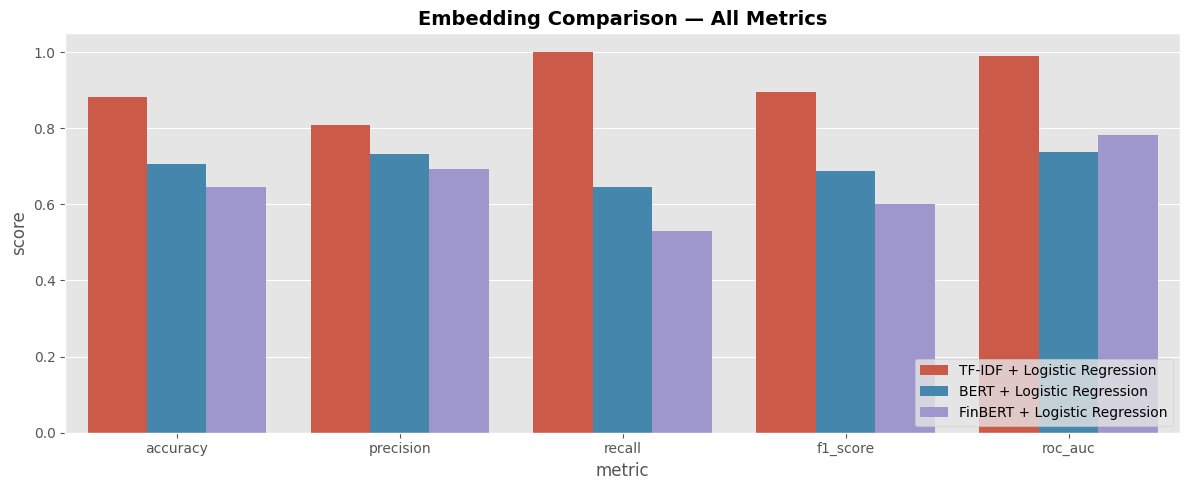

In [13]:
if len(comparison_df) >= 1:
    metrics = ["accuracy", "precision", "recall", "f1_score", "roc_auc"]
    comp_melt = comparison_df.melt(id_vars="model", value_vars=metrics,
                                    var_name="metric", value_name="score")

    plt.figure(figsize=(12, 5))
    sns.barplot(data=comp_melt, x="metric", y="score", hue="model")
    plt.title("Embedding Comparison — All Metrics", fontsize=14, fontweight="bold")
    plt.ylim(0, 1.05)
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.show()

### Confusion matrices

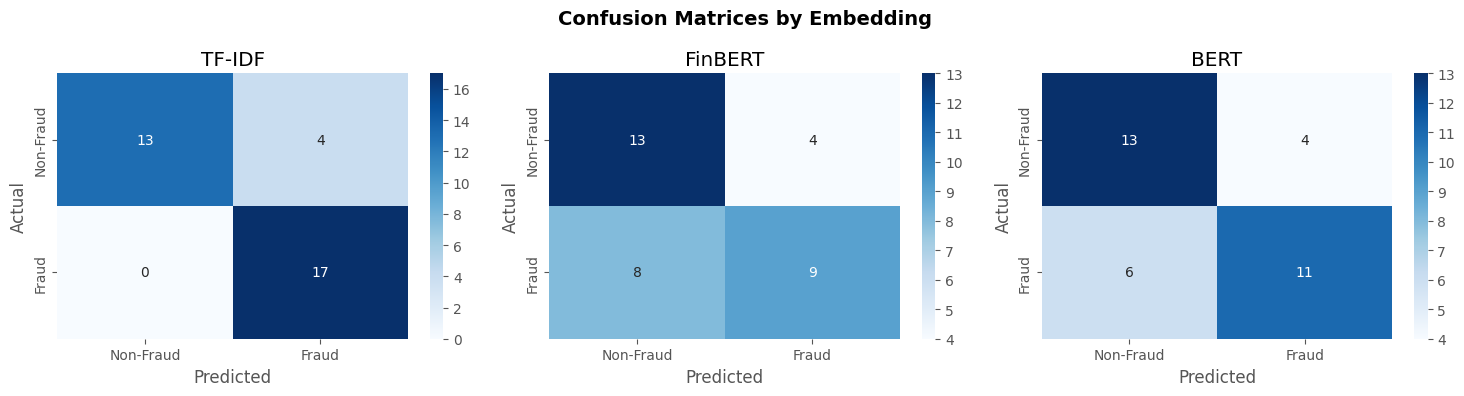

In [15]:
n_models = len(predictions_dict)
fig, axes = plt.subplots(1, n_models, figsize=(5 * n_models, 4))
if n_models == 1:
    axes = [axes]

for ax, (name, preds) in zip(axes, predictions_dict.items()):
    plot_confusion(y_test, preds, name, ax=ax)

plt.suptitle("Confusion Matrices by Embedding", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

### ROC curves

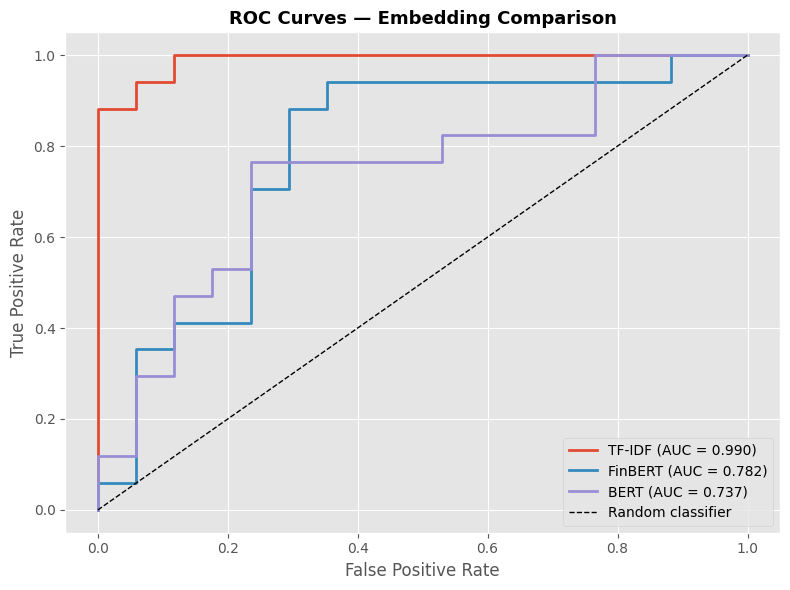

In [16]:
plt.figure(figsize=(8, 6))

for name, proba in probas_dict.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, lw=2, label=f"{name} (AUC = {auc:.3f})")

plt.plot([0, 1], [0, 1], "k--", lw=1, label="Random classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — Embedding Comparison", fontsize=13, fontweight="bold")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

## 7. Select best embedding

In [17]:
best_row = comparison_df.iloc[0]
best_embedding_name = best_row["model"]

print(f"Best embedding (by F1): {best_embedding_name}")
print(f"  F1-score : {best_row['f1_score']:.4f}")
print(f"  Recall   : {best_row['recall']:.4f}")
print(f"  ROC-AUC  : {best_row['roc_auc']:.4f}")

print()
print("This embedding will be passed to Notebook 03 for classifier comparison.")

Best embedding (by F1): TF-IDF + Logistic Regression
  F1-score : 0.8947
  Recall   : 1.0000
  ROC-AUC  : 0.9896

This embedding will be passed to Notebook 03 for classifier comparison.


## 8. Interpretation and Conclusions

### Reading the results

| Outcome | Conclusion |
|---------|------------|
| **TF-IDF wins or ties** | Lexical features are sufficient; simpler model is preferred for deployment and interpretability |
| **FinBERT wins** | Contextual, domain-specific financial language understanding adds a meaningful signal |

### Key takeaways
- For **small datasets (~170 rows)**, TF-IDF often performs competitively because transformer models need more data to generalize
- **Cross-validation** is more reliable than a single train/test split at this scale — compare CV F1 scores, not just test set scores
- **FinBERT** adds interpretive value regardless of performance: it is the industry-standard approach for financial NLP
- The selected embedding carries into **Notebook 03** where multiple classifiers are compared on it

### Selected embedding for Notebook 03
> Based on the F1-score comparison above, **[fill in after running]** is selected as the primary representation.